# 연속데이터예측_아이오와에임스지역_집값예측_train

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("./data/house_train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

결측값 처리

In [4]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [5]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageFinish      5.547945
GarageYrBlt       5.547945
GarageType        5.547945
GarageCond        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtFinType1      2.534247
BsmtQual          2.534247
BsmtCond          2.534247
MasVnrArea        0.547945
Electrical        0.068493
1stFlrSF          0.000000
2ndFlrSF          0.000000
LowQualFinSF      0.000000
GrLivArea         0.000000
BsmtFullBath      0.000000
BsmtHalfBath      0.000000
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
KitchenAbvGr      0.000000
KitchenQual       0.000000
TotRmsAbvGrd      0.000000
Functional        0.000000
Fireplaces        0.000000
CentralAir        0.000000
GarageArea        0.000000
SalePrice         0.000000
Utilities         0.000000
L

In [6]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False).index

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
       'LotFrontage', 'GarageQual', 'GarageFinish', 'GarageYrBlt',
       'GarageType', 'GarageCond', 'BsmtExposure', 'BsmtFinType2',
       'BsmtFinType1', 'BsmtQual', 'BsmtCond', 'MasVnrArea', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'CentralAir',
       'GarageArea', 'SalePrice', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'MSSubClass',
       'MSZoning', 'LotArea', 'Street', 'LotShape', 'GarageCars', 'MiscVal',
       'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'LandContour',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'Exterior2nd', 'ExterQual', 'HeatingQC',
       'Foundation', 'Ho

In [7]:
data = data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], axis=1)

In [8]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

LotFrontage      17.739726
GarageType        5.547945
GarageYrBlt       5.547945
GarageFinish      5.547945
GarageQual        5.547945
GarageCond        5.547945
BsmtFinType2      2.602740
BsmtExposure      2.602740
BsmtQual          2.534247
BsmtCond          2.534247
BsmtFinType1      2.534247
MasVnrArea        0.547945
Electrical        0.068493
FullBath          0.000000
BsmtHalfBath      0.000000
BsmtFullBath      0.000000
GrLivArea         0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
LowQualFinSF      0.000000
2ndFlrSF          0.000000
1stFlrSF          0.000000
KitchenAbvGr      0.000000
KitchenQual       0.000000
SaleCondition     0.000000
SaleType          0.000000
YrSold            0.000000
MoSold            0.000000
MiscVal           0.000000
PoolArea          0.000000
ScreenPorch       0.000000
Fireplaces        0.000000
EnclosedPorch     0.000000
OpenPorchSF       0.000000
WoodDeckSF        0.000000
PavedDrive        0.000000
GarageArea        0.000000
G

In [9]:
missing_cols = (data.isna().sum() / len(data) * 100).sort_values(ascending=False).index
missing_cols

Index(['LotFrontage', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageQual', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtQual',
       'BsmtCond', 'BsmtFinType1', 'MasVnrArea', 'Electrical', 'FullBath',
       'BsmtHalfBath', 'BsmtFullBath', 'GrLivArea', 'HalfBath', 'BedroomAbvGr',
       'LowQualFinSF', '2ndFlrSF', '1stFlrSF', 'KitchenAbvGr', 'KitchenQual',
       'SaleCondition', 'SaleType', 'YrSold', 'MoSold', 'MiscVal', 'PoolArea',
       'ScreenPorch', 'Fireplaces', 'EnclosedPorch', 'OpenPorchSF',
       'WoodDeckSF', 'PavedDrive', 'GarageArea', 'GarageCars', 'Functional',
       'TotRmsAbvGrd', '3SsnPorch', 'OverallQual', 'HouseStyle', 'BldgType',
       'Condition2', 'Condition1', 'Neighborhood', 'LandSlope', 'Heating',
       'Utilities', 'LandContour', 'LotShape', 'Street', 'LotArea', 'MSZoning',
       'MSSubClass', 'Id', 'LotConfig', 'CentralAir', 'HeatingQC', 'SalePrice',
       'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'BsmtFinSF1', 'OverallCond',
       

In [10]:
missing_cols = ['LotFrontage', 'GarageYrBlt', 'GarageCond', 'GarageType',
       'GarageFinish', 'GarageQual', 'BsmtFinType2', 'BsmtExposure',
       'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrArea', 'Electrical']

In [11]:
data['GarageQual'].dtype

dtype('O')

In [12]:
for col in missing_cols:
#     print(col, data[col].dtype)
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [13]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

SalePrice        0.0
Id               0.0
MSSubClass       0.0
GarageArea       0.0
GarageQual       0.0
GarageCond       0.0
PavedDrive       0.0
WoodDeckSF       0.0
OpenPorchSF      0.0
EnclosedPorch    0.0
3SsnPorch        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrArea       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinSF1       0.0
BsmtFinType2     0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath     0.0
BsmtHalfBath     0.0
FullBath     

이상값 탐지

In [14]:
# !pip install seaborn

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

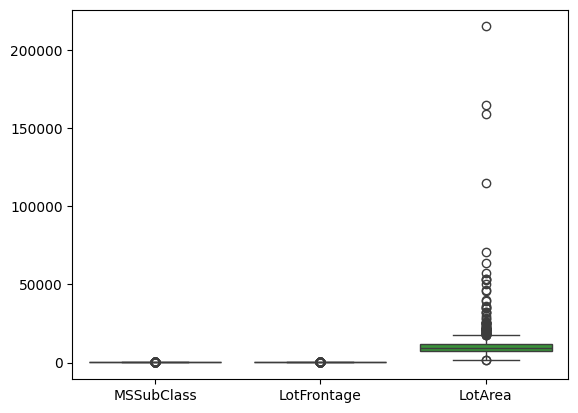

In [16]:
sns.boxplot(data.iloc[:, 1:5])

<Axes: >

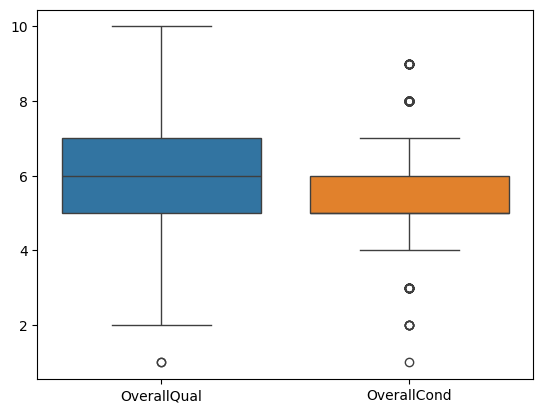

In [17]:
sns.boxplot(data.iloc[:, 16:18])

<Axes: >

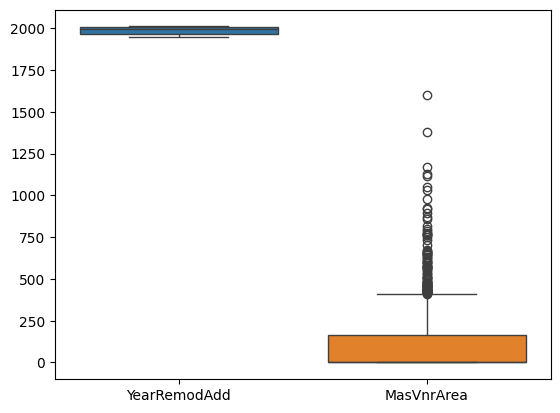

In [18]:
sns.boxplot(data.iloc[:, 19:25])

In [19]:
data2 = data.copy()
data3 = data.copy()

In [20]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [21]:
X = data.drop(["SalePrice", "Id"], axis=1)
y = data["SalePrice"]

In [22]:
X.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal


In [23]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [24]:
X = pd.get_dummies(X)
X.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


In [25]:
X = X.astype('float32')

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
rs = RobustScaler()
rs_X_train = rs.fit_transform(X_train)
rs_X_valid = rs.fit_transform(X_valid)

In [29]:
import joblib
joblib.dump(rs, "./model/iowa_rs.joblib")

['./model/iowa_rs.joblib']

# 출력층 Dense(1)
# model.compile(loss='mean_squared_error', metrics='mse')

In [30]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError

2025-05-22 23:36:15.910141: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-22 23:36:15.928009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747924575.943320   59150 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747924575.948044   59150 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747924575.959300   59150 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [31]:
inputs = Input(shape=(rs_X_train.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
base_model = Model(inputs=inputs, outputs=outputs)
base_model.summary()

I0000 00:00:1747924577.892701   59150 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 266)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
base_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_base_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
base_model_history = base_model.fit(rs_X_train, y_train, epochs=1000, batch_size=32,
                                   validation_data=(rs_X_valid, y_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000


I0000 00:00:1747924579.269220   59199 service.cc:152] XLA service 0x7f0c68003da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747924579.269260   59199 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-22 23:36:19.288257: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747924579.412145   59199 cuda_dnn.cc:529] Loaded cuDNN version 90300


15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42359607296.0000 - root_mean_squared_error: 205666.8438

I0000 00:00:1747924580.407667   59199 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 40586940416.0000 - root_mean_squared_error: 201349.1719
Epoch 1: val_loss improved from inf to 39376543744.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 40535601152.0000 - root_mean_squared_error: 201223.8125 - val_loss: 39376543744.0000 - val_root_mean_squared_error: 198435.2344
Epoch 2/1000
17/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38622228480.0000 - root_mean_squared_error: 196483.0938 
Epoch 2: val_loss improved from 39376543744.00000 to 39368286208.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38666752000.0000 - root_mean_squared_error: 196615.4688 - val_loss: 39368286208.0000 - val_root_mean_squared_error: 198414.4219
Epoch 3/1000
18/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36502822912.0000 - root_mean_squared_error: 190999.8594 
Epoch 3: val_loss improved from 39368286208.00000 to 39353692160.00000, saving 

...

25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3806833408.0000 - root_mean_squared_error: 61652.3008
Epoch 120: val_loss did not improve from 2653918208.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3876465408.0000 - root_mean_squared_error: 62215.7773 - val_loss: 2694939392.0000 - val_root_mean_squared_error: 51912.8047
Epoch 121/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4721970176.0000 - root_mean_squared_error: 68535.2734
Epoch 121: val_loss did not improve from 2653918208.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4728167936.0000 - root_mean_squared_error: 68591.1172 - val_loss: 2668910848.0000 - val_root_mean_squared_error: 51661.5039
Epoch 122/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3808941824.0000 - root_mean_squared_error: 61660.8242
Epoch 122: val_loss improved from 2653918208.00000 to 2611022592.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3930301952.0000 - root_mean_squared_er

Epoch 138/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4082166784.0000 - root_mean_squared_error: 63667.5664 
Epoch 138: val_loss did not improve from 2201608960.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4074624768.0000 - root_mean_squared_error: 63628.5469 - val_loss: 2220210688.0000 - val_root_mean_squared_error: 47119.1094
Epoch 139/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3657473536.0000 - root_mean_squared_error: 60364.8711
Epoch 139: val_loss did not improve from 2201608960.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3720500224.0000 - root_mean_squared_error: 60882.2109 - val_loss: 2240869632.0000 - val_root_mean_squared_error: 47337.8242
Epoch 140/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4436072448.0000 - root_mean_squared_error: 66274.7188
Epoch 140: val_loss did not improve from 2201608960.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4421496832.0000 - root_mean_squared_error: 66183.7266 - val_loss: 2273742336.0000 - v

Epoch 157/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3425208064.0000 - root_mean_squared_error: 58393.0391
Epoch 157: val_loss did not improve from 2106905216.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3479095040.0000 - root_mean_squared_error: 58854.9414 - val_loss: 2132071808.0000 - val_root_mean_squared_error: 46174.3633
Epoch 158/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3790174720.0000 - root_mean_squared_error: 61332.9609
Epoch 158: val_loss did not improve from 2106905216.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3764225536.0000 - root_mean_squared_error: 61161.0430 - val_loss: 2110055808.0000 - val_root_mean_squared_error: 45935.3438
Epoch 159/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3776395008.0000 - root_mean_squared_error: 61257.8359
Epoch 159: val_loss did not improve from 2106905216.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3847569920.0000 - root_mean_squared_error: 61849.4297 - val_loss: 2108707328.0000 - va

Epoch 176/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3222086400.0000 - root_mean_squared_error: 56706.2617
Epoch 176: val_loss improved from 2068278144.00000 to 2053292544.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3292793344.0000 - root_mean_squared_error: 57310.0703 - val_loss: 2053292544.0000 - val_root_mean_squared_error: 45313.2695
Epoch 177/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4583858176.0000 - root_mean_squared_error: 67466.4141
Epoch 177: val_loss did not improve from 2053292544.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4458766848.0000 - root_mean_squared_error: 66560.4531 - val_loss: 2097225472.0000 - val_root_mean_squared_error: 45795.4727
Epoch 178/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4423741440.0000 - root_mean_squared_error: 66466.1719
Epoch 178: val_loss did not improve from 2053292544.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4393725952.0000 - roo

Epoch 195/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4477184512.0000 - root_mean_squared_error: 66636.8438
Epoch 195: val_loss did not improve from 2006528640.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4442999296.0000 - root_mean_squared_error: 66410.3047 - val_loss: 2069972096.0000 - val_root_mean_squared_error: 45496.9453
Epoch 196/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4287210496.0000 - root_mean_squared_error: 65420.8125
Epoch 196: val_loss did not improve from 2006528640.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4266112768.0000 - root_mean_squared_error: 65264.7461 - val_loss: 2041082112.0000 - val_root_mean_squared_error: 45178.3359
Epoch 197/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3815466496.0000 - root_mean_squared_error: 61674.2031
Epoch 197: val_loss improved from 2006528640.00000 to 2004577152.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3851886848.0000 - r

In [33]:
pred = base_model.predict(rs_X_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


,pred
0,120881.445312
1,273127.437500
2,79557.406250
3,120337.937500
4,264745.437500
...,...
433,79436.328125
434,109863.359375
435,162280.593750
436,134895.343750


In [34]:
y_valid = pd.DataFrame(y_valid)
y_valid_df = y_valid.reset_index(drop=True)
final_result = y_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,120881.445312
1,325000,273127.437500
2,115000,79557.406250
3,159000,120337.937500
4,315500,264745.437500
...,...,...
433,139000,79436.328125
434,126175,109863.359375
435,205950,162280.593750
436,110000,134895.343750


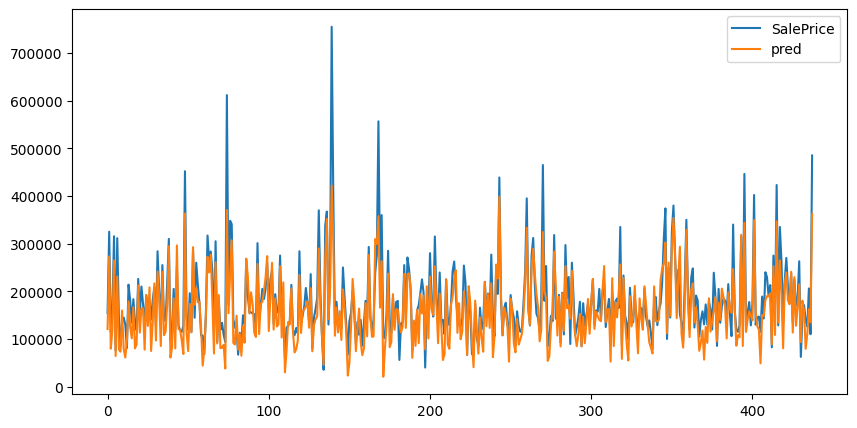

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2041880960.0000 - root_mean_squared_error: 45095.0898
[1915742720.0, 43769.19921875]


In [35]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(base_model.evaluate(rs_X_valid, y_valid))

# 많은 컬럼 중에 어떤 컬럼을 선택? 266개
*  컬럼의 상관분석을 통해 타겟 변수(종속변수)와 상관도가 높은 컬럼만 선택
* 트리계열 알고리즘을 사용해 분석 후 중요한 변수만 추출해서 재분석

In [36]:
data2

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,0,4,2010,WD,Normal,142125


In [37]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [38]:
data2.drop('Id', axis=1, inplace=True)

In [39]:
data2 = pd.get_dummies(data2)
data2.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


상관분석

In [40]:
# data2['SalePrice']

In [41]:
corr_rate = data2.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

In [42]:
new_cols1 = corr_rate.head(15).index
new_cols1

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt',
       'GarageArea', 'FullBath', 'TotalBsmtSF', '1stFlrSF', 'ExterQual_Gd',
       'YearRemodAdd', 'GarageYrBlt', 'Foundation_PConc', 'TotRmsAbvGrd',
       'Fireplaces'],
      dtype='object')

In [43]:
new_cols2 = corr_rate.tail(4).index
new_cols2

Index(['KitchenQual_TA', 'BsmtQual_TA', 'GarageFinish_Unf', 'ExterQual_TA'], dtype='object')

In [44]:
final_cols = list(new_cols1) + list(new_cols2)
final_cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'YearBuilt',
 'GarageArea',
 'FullBath',
 'TotalBsmtSF',
 '1stFlrSF',
 'ExterQual_Gd',
 'YearRemodAdd',
 'GarageYrBlt',
 'Foundation_PConc',
 'TotRmsAbvGrd',
 'Fireplaces',
 'KitchenQual_TA',
 'BsmtQual_TA',
 'GarageFinish_Unf',
 'ExterQual_TA']

In [45]:
data2

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [46]:
final_df = data2[final_cols]

In [47]:
final_df

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
0,208500,7,1710,2,2003,548,2,856,856,True,2003,2003.0,True,8,0,False,False,False,False
1,181500,6,1262,2,1976,460,2,1262,1262,False,1976,1976.0,False,6,1,True,False,False,True
2,223500,7,1786,2,2001,608,2,920,920,True,2002,2001.0,True,6,1,False,False,False,False
3,140000,7,1717,3,1915,642,1,756,961,False,1970,1998.0,False,7,1,False,True,True,True
4,250000,8,2198,3,2000,836,2,1145,1145,True,2000,2000.0,True,9,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,1999,460,2,953,953,False,2000,1999.0,True,7,1,True,False,False,True
1456,210000,6,2073,2,1978,500,2,1542,2073,False,1988,1978.0,False,7,2,True,False,True,True
1457,266500,7,2340,1,1941,252,2,1152,1188,False,2006,1941.0,False,9,2,False,True,False,False
1458,142125,5,1078,1,1950,240,1,1078,1078,False,1996,1950.0,False,5,0,False,True,True,True


In [48]:
final_df.corr(method='spearman')

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
SalePrice,1.000000,0.809829,0.731310,0.690711,0.652682,0.649379,0.635957,0.602725,0.575408,0.574642,0.571159,0.563256,0.562287,0.532586,0.519247,-0.581803,-0.583512,-0.620915,-0.637785
OverallQual,0.809829,1.000000,0.603262,0.608756,0.647392,0.541552,0.576372,0.459915,0.408730,0.603276,0.557723,0.592010,0.586764,0.427806,0.420626,-0.581192,-0.590344,-0.556712,-0.673842
GrLivArea,0.731310,0.603262,1.000000,0.505094,0.288493,0.468211,0.658419,0.371026,0.494421,0.358133,0.282400,0.274625,0.332373,0.827874,0.480804,-0.376159,-0.338674,-0.362334,-0.413922
GarageCars,0.690711,0.608756,0.505094,1.000000,0.601519,0.853317,0.518310,0.455508,0.450580,0.443029,0.456245,0.564786,0.480178,0.386244,0.325520,-0.423255,-0.504415,-0.489950,-0.506121
YearBuilt,0.652682,0.647392,0.288493,0.601519,1.000000,0.528281,0.537420,0.427187,0.293363,0.593575,0.684388,0.845595,0.704001,0.176820,0.174655,-0.512248,-0.700552,-0.632360,-0.644772
GarageArea,0.649379,0.541552,0.468211,0.853317,0.528281,1.000000,0.444459,0.486685,0.489797,0.389859,0.398267,0.540450,0.400205,0.330549,0.264543,-0.393538,-0.413167,-0.449457,-0.453014
FullBath,0.635957,0.576372,0.658419,0.518310,0.537420,0.444459,1.000000,0.328036,0.366891,0.449973,0.431390,0.524892,0.480765,0.558665,0.268548,-0.430333,-0.513693,-0.450629,-0.485598
TotalBsmtSF,0.602725,0.459915,0.371026,0.455508,0.427187,0.486685,0.328036,1.000000,0.829292,0.313044,0.299042,0.319936,0.296406,0.233913,0.325687,-0.307764,-0.317195,-0.385379,-0.383999
1stFlrSF,0.575408,0.408730,0.494421,0.450580,0.293363,0.489797,0.366891,0.829292,1.000000,0.225259,0.240265,0.214327,0.179926,0.361777,0.394883,-0.268281,-0.215559,-0.326525,-0.294636
ExterQual_Gd,0.574642,0.603276,0.358133,0.443029,0.593575,0.389859,0.449973,0.313044,0.225259,1.000000,0.532550,0.569570,0.586748,0.212665,0.181413,-0.617598,-0.541969,-0.483784,-0.906121


<Axes: >

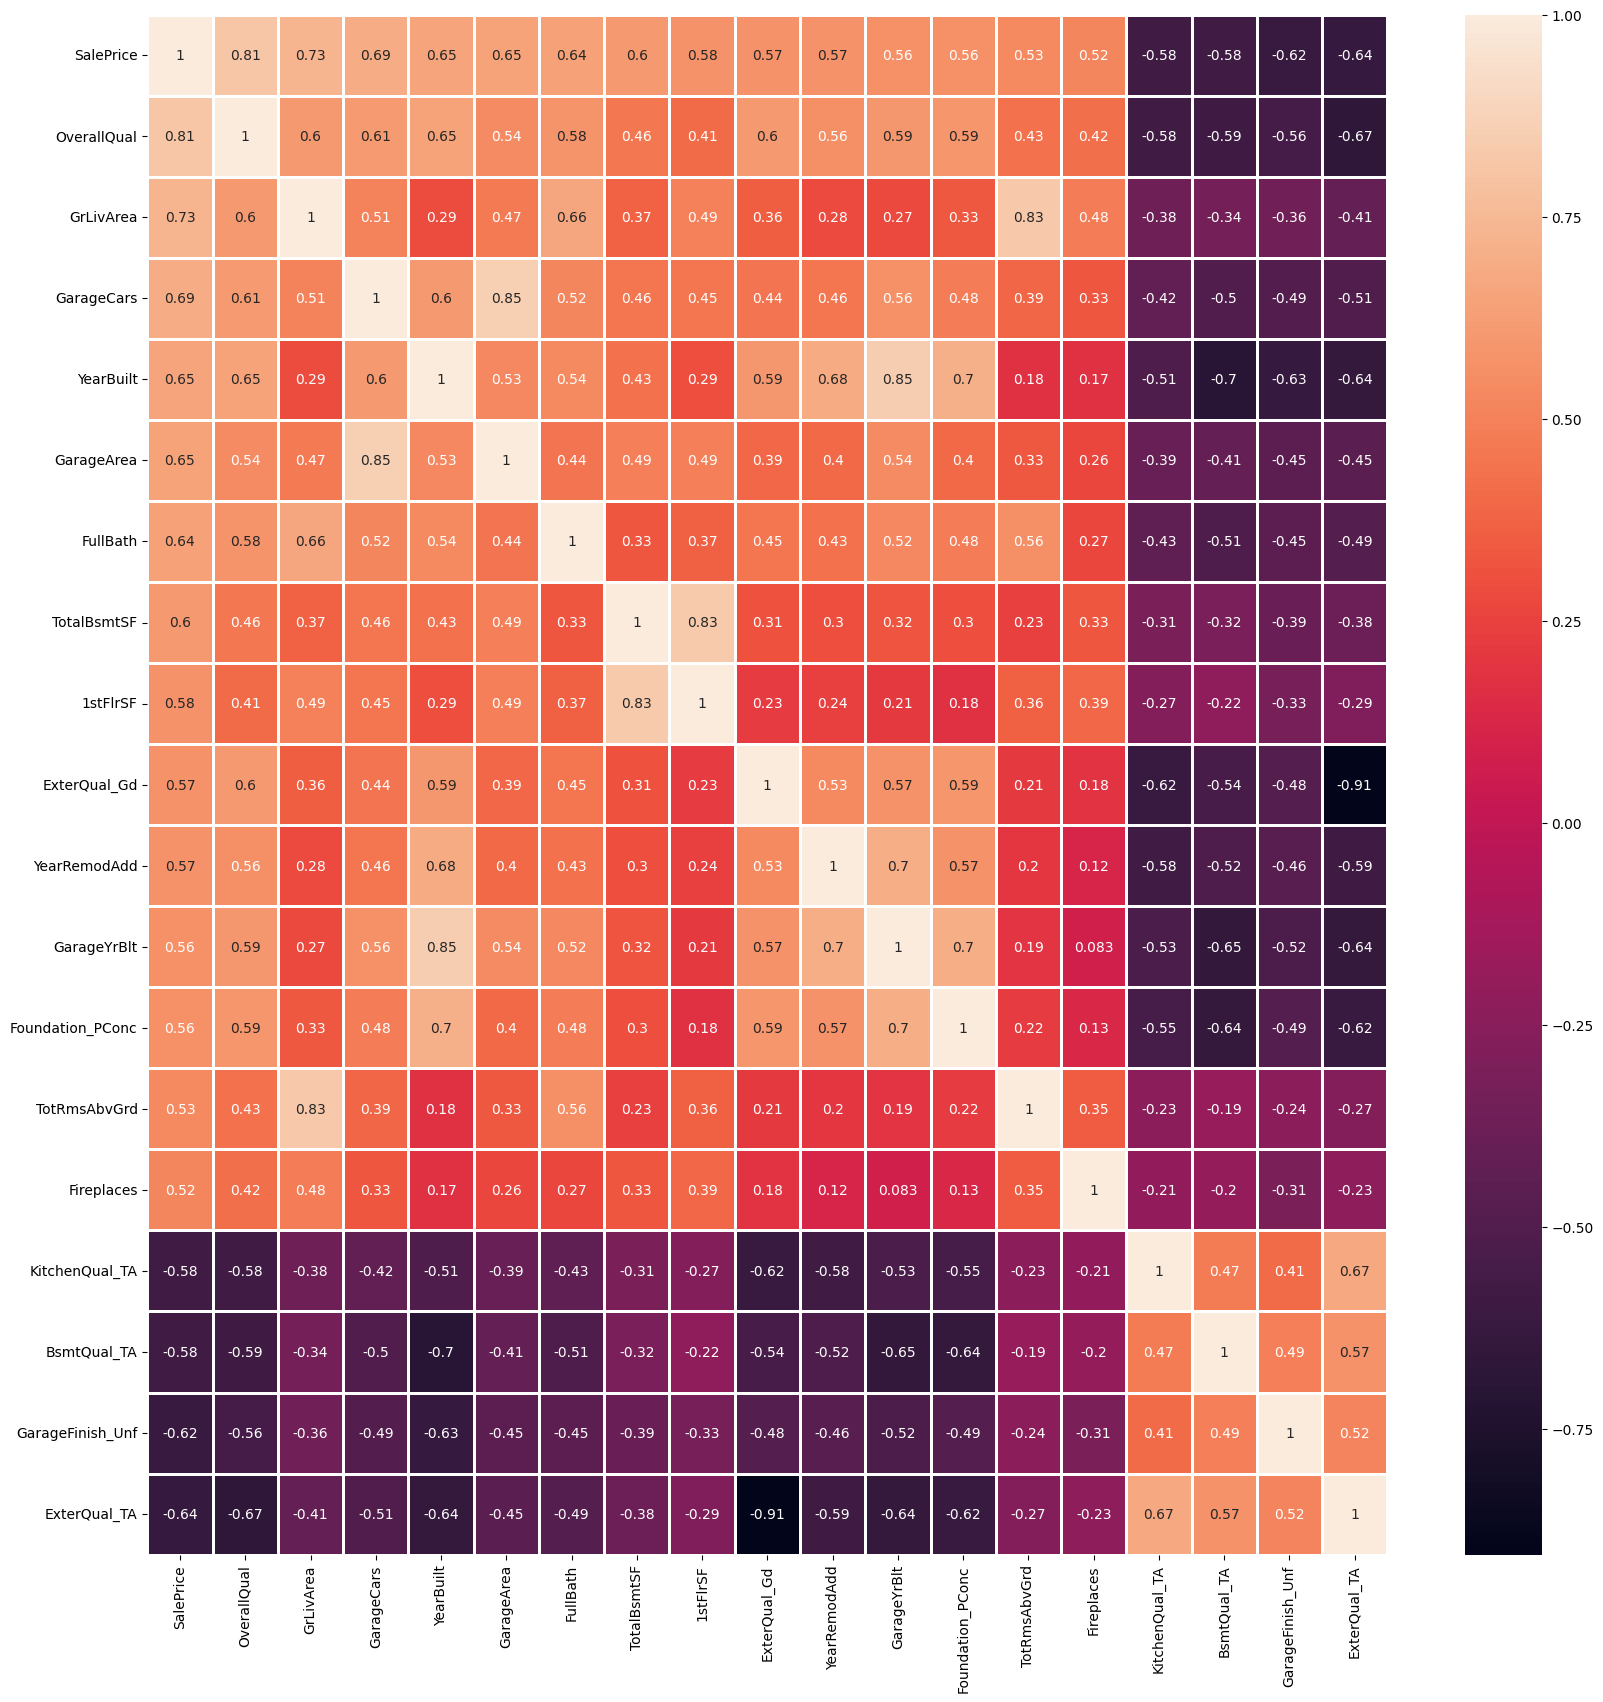

In [49]:
plt.figure(figsize=(20,20))
sns.heatmap(final_df.corr(method='spearman'), annot=True, linewidths=1)

In [50]:
# ExterQual_TA - ExterQual_Gd  -0.91
# BsmtQual_TA - YearBuilt  -0.7
# GarageYrBlt - YearBuilt  0.7
# TotRmsAbvGrd - GrLivArea  0.83

In [51]:
final_df = final_df.drop(['BsmtQual_TA', 'TotRmsAbvGrd', 'ExterQual_Gd'], axis=1)

In [52]:
X2 = final_df.drop('SalePrice', axis=1)
y2 = final_df['SalePrice']

In [53]:
X2

,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,YearRemodAdd,GarageYrBlt,Foundation_PConc,Fireplaces,KitchenQual_TA,GarageFinish_Unf,ExterQual_TA
0,7,1710,2,2003,548,2,856,856,2003,2003.0,True,0,False,False,False
1,6,1262,2,1976,460,2,1262,1262,1976,1976.0,False,1,True,False,True
2,7,1786,2,2001,608,2,920,920,2002,2001.0,True,1,False,False,False
3,7,1717,3,1915,642,1,756,961,1970,1998.0,False,1,False,True,True
4,8,2198,3,2000,836,2,1145,1145,2000,2000.0,True,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,1999,460,2,953,953,2000,1999.0,True,1,True,False,True
1456,6,2073,2,1978,500,2,1542,2073,1988,1978.0,False,2,True,True,True
1457,7,2340,1,1941,252,2,1152,1188,2006,1941.0,False,2,False,False,False
1458,5,1078,1,1950,240,1,1078,1078,1996,1950.0,False,0,False,True,True


In [54]:
X2_train, X2_valid, y2_train, y2_valid = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [55]:
rs2 = RobustScaler()
rs2_X2_train = rs2.fit_transform(X2_train)
rs2_X2_valid = rs2.transform(X2_valid)

In [56]:
rs2_X2_train = rs2_X2_train.astype('float32')
rs2_X2_valid = rs2_X2_valid.astype('float32')

In [57]:
inputs = Input(shape=(rs2_X2_train.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
corr_select_model = Model(inputs=inputs, outputs=outputs)
corr_select_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
corr_select_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_corr_select_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
corr_select_model_history = corr_select_model.fit(rs2_X2_train, y2_train, epochs=1000, batch_size=32,
                                   validation_data=(rs2_X2_valid, y2_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 39552806912.0000 - root_mean_squared_error: 198822.3125
Epoch 1: val_loss improved from inf to 39380754432.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 39532810240.0000 - root_mean_squared_error: 198773.5469 - val_loss: 39380754432.0000 - val_root_mean_squared_error: 198445.8438
Epoch 2/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41099927552.0000 - root_mean_squared_error: 202656.3906
Epoch 2: val_loss improved from 39380754432.00000 to 39380480000.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 40462430208.0000 - root_mean_squared_error: 201081.3906 - val_loss: 39380480000.0000 - val_root_mean_squared_error: 198445.1562
Epoch 3/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 37364121600.0000 - root_mean_squared_error: 193123.3125
Epoch 3: val_loss improved from 39380480000.00000 to 

Epoch 18/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 41345904640.0000 - root_mean_squared_error: 203106.0625 
Epoch 18: val_loss improved from 39003422720.00000 to 38922620928.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 41091969024.0000 - root_mean_squared_error: 202491.6875 - val_loss: 38922620928.0000 - val_root_mean_squared_error: 197288.1719
Epoch 19/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36777848832.0000 - root_mean_squared_error: 191734.6562
Epoch 19: val_loss improved from 38922620928.00000 to 38834876416.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 36960415744.0000 - root_mean_squared_error: 192210.7969 - val_loss: 38834876416.0000 - val_root_mean_squared_error: 197065.6562
Epoch 20/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39070650368.0000 - root_mean_squared_error: 197574.2969 
Epoch 20: val_loss improved from 

Epoch 35/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37074894848.0000 - root_mean_squared_error: 192514.8906
Epoch 35: val_loss improved from 36095447040.00000 to 35814621184.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 36831539200.0000 - root_mean_squared_error: 191881.0312 - val_loss: 35814621184.0000 - val_root_mean_squared_error: 189247.5156
Epoch 36/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 34869612544.0000 - root_mean_squared_error: 186696.0312
Epoch 36: val_loss improved from 35814621184.00000 to 35520155648.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 34923499520.0000 - root_mean_squared_error: 186846.9062 - val_loss: 35520155648.0000 - val_root_mean_squared_error: 188467.9062
Epoch 37/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33462067200.0000 - root_mean_squared_error: 182896.8281
Epoch 37: val_loss improved from 35

Epoch 52/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30356049920.0000 - root_mean_squared_error: 174189.6406
Epoch 52: val_loss improved from 29806422016.00000 to 29355522048.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 30195818496.0000 - root_mean_squared_error: 173731.7969 - val_loss: 29355522048.0000 - val_root_mean_squared_error: 171334.5312
Epoch 53/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28977797120.0000 - root_mean_squared_error: 170220.0156
Epoch 53: val_loss improved from 29355522048.00000 to 28896870400.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 28975577088.0000 - root_mean_squared_error: 170213.7656 - val_loss: 28896870400.0000 - val_root_mean_squared_error: 169990.7969
Epoch 54/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28467154944.0000 - root_mean_squared_error: 168712.7969
Epoch 54: val_loss improved from 28

Epoch 69/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20574662656.0000 - root_mean_squared_error: 143401.3125
Epoch 69: val_loss improved from 21516111872.00000 to 21018441728.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 20722964480.0000 - root_mean_squared_error: 143920.0156 - val_loss: 21018441728.0000 - val_root_mean_squared_error: 144977.3750
Epoch 70/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19176927232.0000 - root_mean_squared_error: 138436.9219
Epoch 70: val_loss improved from 21018441728.00000 to 20521246720.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19409483776.0000 - root_mean_squared_error: 139270.9219 - val_loss: 20521246720.0000 - val_root_mean_squared_error: 143252.3906
Epoch 71/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20672980992.0000 - root_mean_squared_error: 143771.7031
Epoch 71: val_loss improved from 2

...

Epoch 313/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4752411648.0000 - root_mean_squared_error: 68825.2812 
Epoch 313: val_loss did not improve from 2590778624.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4749538304.0000 - root_mean_squared_error: 68818.0469 - val_loss: 2592099840.0000 - val_root_mean_squared_error: 50912.6680
Epoch 314/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5973717504.0000 - root_mean_squared_error: 77008.5000
Epoch 314: val_loss improved from 2590778624.00000 to 2579821312.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5846885888.0000 - root_mean_squared_error: 76199.4375 - val_loss: 2579821312.0000 - val_root_mean_squared_error: 50791.9414
Epoch 315/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4086283520.0000 - root_mean_squared_error: 63842.6758
Epoch 315: val_loss improved from 2579821312.00000 to 2568996864.00000, saving model to ./model/iowa_corr_select_model_

27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6457069056.0000 - root_mean_squared_error: 79923.6641
Epoch 349: val_loss improved from 2482543104.00000 to 2478999040.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6203022336.0000 - root_mean_squared_error: 78324.9219 - val_loss: 2478999040.0000 - val_root_mean_squared_error: 49789.5469
Epoch 350/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4467487232.0000 - root_mean_squared_error: 66799.5234
Epoch 350: val_loss improved from 2478999040.00000 to 2455370752.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4522912256.0000 - root_mean_squared_error: 67204.4531 - val_loss: 2455370752.0000 - val_root_mean_squared_error: 49551.6953
Epoch 351/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5174226944.0000 - root_mean_squared_error: 71905.5781
Epoch 351: val_loss did not improve from 2455370752.00000
32/32

Epoch 367/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5966292992.0000 - root_mean_squared_error: 76929.2109
Epoch 367: val_loss did not improve from 2378970624.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5823252992.0000 - root_mean_squared_error: 76041.1875 - val_loss: 2380059904.0000 - val_root_mean_squared_error: 48785.8594
Epoch 368/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5340185600.0000 - root_mean_squared_error: 72934.2188
Epoch 368: val_loss improved from 2378970624.00000 to 2377271552.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5349367296.0000 - root_mean_squared_error: 73022.3594 - val_loss: 2377271552.0000 - val_root_mean_squared_error: 48757.2734
Epoch 369/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4136305408.0000 - root_mean_squared_error: 64160.5859
Epoch 369: val_loss improved from 2377271552.00000 to 2374543360.00000, saving model to ./model/iowa_corr_select_model_b

Epoch 386/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5267665920.0000 - root_mean_squared_error: 72359.8750
Epoch 386: val_loss improved from 2351489024.00000 to 2351385856.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5218399232.0000 - root_mean_squared_error: 72031.1562 - val_loss: 2351385856.0000 - val_root_mean_squared_error: 48491.0898
Epoch 387/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4149187584.0000 - root_mean_squared_error: 64391.7305
Epoch 387: val_loss improved from 2351385856.00000 to 2327868672.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4165333504.0000 - root_mean_squared_error: 64520.0234 - val_loss: 2327868672.0000 - val_root_mean_squared_error: 48247.9922
Epoch 388/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4230475520.0000 - root_mean_squared_error: 65010.4961
Epoch 388: val_loss improved from 2327868672.000

Epoch 422/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5059751424.0000 - root_mean_squared_error: 71039.6641
Epoch 422: val_loss improved from 2187493632.00000 to 2185253888.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5020976640.0000 - root_mean_squared_error: 70773.4297 - val_loss: 2185253888.0000 - val_root_mean_squared_error: 46746.6992
Epoch 423/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4696190464.0000 - root_mean_squared_error: 68513.8125
Epoch 423: val_loss improved from 2185253888.00000 to 2173240576.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4695540224.0000 - root_mean_squared_error: 68509.9766 - val_loss: 2173240576.0000 - val_root_mean_squared_error: 46618.0273
Epoch 424/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4351006208.0000 - root_mean_squared_error: 65933.8516
Epoch 424: val_loss improved from 2173240576.00

In [59]:
pred = corr_select_model.predict(rs2_X2_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


,pred
0,76577.664062
1,303436.031250
2,108167.882812
3,127040.859375
4,284180.125000
...,...
433,71806.062500
434,72511.726562
435,197338.062500
436,119084.500000


In [60]:
y2_valid = pd.DataFrame(y2_valid)
y2_valid_df = y2_valid.reset_index(drop=True)
final_result = y2_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,76577.664062
1,325000,303436.031250
2,115000,108167.882812
3,159000,127040.859375
4,315500,284180.125000
...,...,...
433,139000,71806.062500
434,126175,72511.726562
435,205950,197338.062500
436,110000,119084.500000


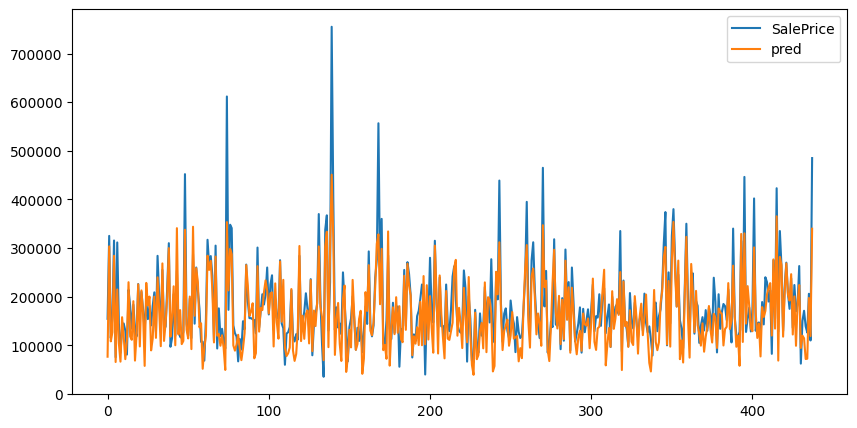

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2206575360.0000 - root_mean_squared_error: 46863.5625
[2157242624.0, 46446.125]


In [61]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(corr_select_model.evaluate(rs2_X2_valid, y2_valid))